In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adityajn105/flickr30k/captions.txt


In [ ]:
import os
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split
from torch.nn.utils.rnn import pack_padded_sequence
from PIL import Image
from tqdm import tqdm
import pickle
import pandas as pd
import numpy as np
import re
from collections import Counter
from nltk.translate.bleu_score import corpus_bleu
import time
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = '/kaggle/input'
image_dir = None
caption_path = None

for root, dirs, files in os.walk(base_path):
    jpgs = [f for f in files if f.lower().endswith('.jpg')]
    if len(jpgs) > 1000:
        image_dir = root
        break

for root, dirs, files in os.walk(base_path):
    if 'captions.txt' in files:
        caption_path = os.path.join(root, 'captions.txt')
    elif 'results.csv' in files:
        caption_path = os.path.join(root, 'results.csv')

print(f"Image Directory: {image_dir}")
print(f"Caption File: {caption_path}")

Image Directory: /kaggle/input/datasets/adityajn105/flickr30k/Images
Caption File: /kaggle/input/datasets/adityajn105/flickr30k/Images/results.csv


In [2]:
class FlickrFeatureDataset(Dataset):
    def __init__(self, img_dir, transform):
        self.img_dir = img_dir
        self.img_names = [f for f in os.listdir(img_dir) if f.lower().endswith('.jpg')]
        self.transform = transform
        
    def __len__(self):
        return len(self.img_names)
    
    def __getitem__(self, idx):
        name = self.img_names[idx]
        path = os.path.join(self.img_dir, name)
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img), name
        except:
            return None, None

resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
modules = list(resnet.children())[:-1]
model_resnet = nn.Sequential(*modules).to(device)
model_resnet.eval()

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

feature_dataset = FlickrFeatureDataset(image_dir, transform)
feature_loader = DataLoader(feature_dataset, batch_size=128, num_workers=2, shuffle=False)

features_dict = {}
FEATURE_FILE = 'flickr30k_features.pkl'

if os.path.exists(FEATURE_FILE):
    print("Loading existing features...")
    with open(FEATURE_FILE, 'rb') as f:
        features_dict = pickle.load(f)
else:
    print("Extracting features...")
    with torch.no_grad():
        for imgs, names in tqdm(feature_loader):
            if imgs is None: continue
            imgs = imgs.to(device)
            feats = model_resnet(imgs).view(imgs.size(0), -1)
            cpu_feats = feats.cpu().numpy()
            
            for i, name in enumerate(names):
                features_dict[name] = cpu_feats[i]

    with open(FEATURE_FILE, 'wb') as f:
        pickle.dump(features_dict, f)

print(f"Total Features: {len(features_dict)}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 107MB/s] 


Extracting features...


100%|██████████| 249/249 [03:44<00:00,  1.11it/s]


Total Features: 31783


In [3]:
class Vocabulary:
    def __init__(self, freq_threshold=5):
        self.itos = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        self.stoi = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    def tokenizer_eng(self, text):
        return text.split()

    def build_vocabulary(self, sentence_list):
        frequencies = Counter()
        idx = 4
        for sentence in sentence_list:
            for word in self.tokenizer_eng(sentence):
                frequencies[word] += 1
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1
                    
    def numericalize(self, text):
        tokenized_text = self.tokenizer_eng(text)
        return [self.stoi[token] if token in self.stoi else self.stoi["<unk>"] for token in tokenized_text]

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z]+', ' ', text)
    text = " ".join(text.split())
    return text

captions_dict = {}
all_captions_list = []

with open(caption_path, 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if i == 0: continue
        
        if '|' in line:
            parts = line.split('|')
            img_id = parts[0].strip()
            caption = parts[-1].strip()
        elif ',' in line:
            parts = line.split(',')
            img_id = parts[0].strip()
            caption = " ".join(parts[1:]).strip()
        else:
            continue

        if not img_id.endswith('.jpg'):
            img_id = img_id + '.jpg'
            
        if img_id in features_dict:
            cleaned_caption = clean_text(caption)
            if img_id not in captions_dict:
                captions_dict[img_id] = []
            captions_dict[img_id].append(cleaned_caption)
            all_captions_list.append(cleaned_caption)

vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(all_captions_list)

with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

print(f"Vocabulary Size: {len(vocab)}")

Vocabulary Size: 7611


In [4]:
class FlickrTrainDataset(Dataset):
    def __init__(self, features, captions_dict, vocab):
        self.vocab = vocab
        self.features = features
        self.captions_dict = captions_dict
        self.imgs = []
        self.captions = []
        
        for img_id, caps in captions_dict.items():
            for cap in caps:
                self.imgs.append(img_id)
                self.captions.append(cap)

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_id = self.imgs[idx]
        caption = self.captions[idx]
        feature = torch.tensor(self.features[img_id])
        
        caption_vec = [self.vocab.stoi["<start>"]]
        caption_vec += self.vocab.numericalize(caption)
        caption_vec.append(self.vocab.stoi["<end>"])
        
        return feature, torch.tensor(caption_vec)

def collate_fn(batch):
    batch.sort(key=lambda x: len(x[1]), reverse=True)
    features, captions = zip(*batch)
    features = torch.stack(features, 0)
    
    lengths = [len(cap) for cap in captions]
    targets = torch.zeros(len(captions), max(lengths)).long()
    for i, cap in enumerate(captions):
        end = lengths[i]
        targets[i, :end] = cap[:end]
        
    return features, targets, lengths

full_dataset = FlickrTrainDataset(features_dict, captions_dict, vocab)

train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=128, shuffle=True, collate_fn=collate_fn, num_workers=2)
val_loader = DataLoader(val_set, batch_size=128, shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Train samples: {len(train_set)}")
print(f"Val samples: {len(val_set)}")

Train samples: 143023
Val samples: 15892


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

# --- 1. Attention Module ---
class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)  # Visual Features
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)  # Hidden State
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)  
        att2 = self.decoder_att(decoder_hidden)  
        att_score = self.full_att(self.relu(att1 + att2.unsqueeze(1))) 
        alpha = self.softmax(att_score)  # Attention Weights
        attention_weighted_encoding = (encoder_out * alpha).sum(dim=1)  
        return attention_weighted_encoding, alpha

# --- 2. Decoder with Attention ---
class DecoderWithAttention(nn.Module):
    def __init__(self, attention_dim, embed_dim, decoder_dim, vocab_size, encoder_dim=2048, dropout=0.5):
        super(DecoderWithAttention, self).__init__()
        self.encoder_dim = encoder_dim
        self.attention_dim = attention_dim
        self.decoder_dim = decoder_dim
        self.vocab_size = vocab_size
        self.dropout = dropout

        self.attention = Attention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout_layer = nn.Dropout(dropout)
        
        # LSTMCell use karenge (Manual Loop ke liye)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim, bias=True)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.fc = nn.Linear(decoder_dim, vocab_size)

    def init_hidden_state(self, encoder_out):
        mean_encoder_out = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder_out)
        c = self.init_c(mean_encoder_out)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        batch_size = encoder_out.size(0)
        vocab_size = self.vocab_size
        
        # Agar features flat hain (Batch, 2048), toh unhe fake 3D banao
        if encoder_out.dim() == 2:
            encoder_out = encoder_out.unsqueeze(1) # (Batch, 1, 2048)

        # Sort Batch (descending lengths) - Attention ke liye zaroori hai
        captions = captions[:, :-1] # Remove <end> token for input
        embeddings = self.embedding(captions)
        
        h, c = self.init_hidden_state(encoder_out)
        
        decode_len = captions.size(1)
        predictions = torch.zeros(batch_size, decode_len, vocab_size).to(encoder_out.device)
        alphas = torch.zeros(batch_size, decode_len, encoder_out.size(1)).to(encoder_out.device)
        
        for t in range(decode_len):
            # Attention Mechanism
            attention_weighted_encoding, alpha = self.attention(encoder_out, h)
            gate = torch.sigmoid(self.f_beta(h))
            attention_weighted_encoding = gate * attention_weighted_encoding
            
            # LSTM Step
            lstm_input = torch.cat((embeddings[:, t, :], attention_weighted_encoding), dim=1)
            h, c = self.lstm_cell(lstm_input, (h, c))
            
            preds = self.fc(self.dropout_layer(h))
            predictions[:, t, :] = preds
            alphas[:, t, :] = alpha.squeeze(2)
            
        return predictions, alphas

In [7]:
import torch.optim as optim
from torch.nn.utils.rnn import pack_padded_sequence
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import time
from tqdm.notebook import tqdm
import numpy as np

# --- Hyperparameters ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
learning_rate = 3e-4
epochs = 15
alpha_c = 0.01  # Regularization weight

# --- Initialize Model ---
# Ensure fresh model
model = DecoderWithAttention(attention_dim=256, embed_dim=256, decoder_dim=512, vocab_size=len(vocab), encoder_dim=2048).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<pad>"])

# --- Helper: Advanced Metrics Calculation ---
def calculate_metrics(references, hypotheses):
    """
    Calculates BLEU-4, Precision, Recall, and F1 (Unigram based)
    """
    # 1. BLEU Scores
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=SmoothingFunction().method1)
    
    # 2. Precision, Recall, F1 (Unigram - Word Level match)
    total_precision = 0
    total_recall = 0
    count = 0
    
    for ref_list, hyp in zip(references, hypotheses):
        # ref_list is a list of lists (e.g., [['a', 'cat'], ['the', 'cat']]), we take the first/best ref for simple P/R
        ref = set(ref_list[0]) 
        hyp_set = set(hyp)
        
        if len(hyp_set) == 0: continue
        
        # Intersection (Matching words)
        match = len(ref.intersection(hyp_set))
        
        # Precision = Matches / Total Generated
        precision = match / len(hyp_set)
        # Recall = Matches / Total Reference
        recall = match / len(ref) if len(ref) > 0 else 0
        
        total_precision += precision
        total_recall += recall
        count += 1
        
    avg_precision = total_precision / count if count > 0 else 0
    avg_recall = total_recall / count if count > 0 else 0
    
    # F1 Score formula
    if (avg_precision + avg_recall) == 0:
        f1 = 0
    else:
        f1 = 2 * (avg_precision * avg_recall) / (avg_precision + avg_recall)
        
    return bleu4, avg_precision, avg_recall, f1

# --- Helper: Generate Caption ---
def generate_caption_att(model, image_features, vocab, max_len=20):
    model.eval()
    with torch.no_grad():
        if image_features.dim() == 1: image_features = image_features.unsqueeze(0)
        if image_features.dim() == 2: image_features = image_features.unsqueeze(1) 

        h, c = model.init_hidden_state(image_features)
        word_idx = vocab.stoi['<start>']
        captions = []
        
        for _ in range(max_len):
            embed = model.embedding(torch.tensor([word_idx]).to(device))
            att_weight, alpha = model.attention(image_features, h)
            gate = torch.sigmoid(model.f_beta(h))
            att_weight = gate * att_weight
            
            lstm_input = torch.cat((embed, att_weight), dim=1)
            h, c = model.lstm_cell(lstm_input, (h, c))
            output = model.fc(h)
            
            predicted = output.argmax(1)
            word = vocab.itos[predicted.item()]
            if word == '<end>': break
            captions.append(word)
            word_idx = predicted.item()
    return captions

# --- Main Training Loop ---
print(f"🚀 Starting Robust Training on {device}...")
print("ℹ️  Note: 'num_workers=0' is active to prevent freezing.")

history = {'train_loss': [], 'val_loss': [], 'bleu': [], 'f1': []}

for epoch in range(epochs):
    start = time.time()
    model.train()
    train_loss_total = 0
    
    # TQDM Progress Bar
    loop = tqdm(train_loader, total=len(train_loader), leave=True)
    loop.set_description(f"Epoch [{epoch+1}/{epochs}]")
    
    for imgs, caps, lengths in loop:
        imgs, caps = imgs.to(device), caps.to(device)
        
        preds, alphas = model(imgs, caps, lengths)
        targets = caps[:, 1:] 
        
        if isinstance(lengths, list):
            decode_lengths = [l - 1 for l in lengths]
        else:
            decode_lengths = (lengths - 1).tolist()
            
        preds_packed = pack_padded_sequence(preds, decode_lengths, batch_first=True, enforce_sorted=False).data
        targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True, enforce_sorted=False).data
        
        # Main Loss (Cross Entropy)
        loss_ce = criterion(preds_packed, targets_packed)
        
        # Attention Regularization
        att_reg = alpha_c * ((1. - alphas.sum(dim=1)) ** 2).mean()
        
        # Total Loss
        loss = loss_ce + att_reg
        
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient Clipping (Prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        train_loss_total += loss_ce.item() # Recording only CE loss for clarity
        
        # Update Bar
        loop.set_postfix(loss=loss_ce.item())
        
    avg_train_loss = train_loss_total / len(train_loader)
    
    # --- Validation Loop (Metrics) ---
    model.eval()
    val_loss_total = 0
    references, hypotheses = [], []
    
    print("   📊 Running Validation & Metrics...")
    with torch.no_grad():
        # 1. Calc Validation Loss
        for imgs, caps, lengths in val_loader:
            imgs, caps = imgs.to(device), caps.to(device)
            preds, alphas = model(imgs, caps, lengths)
            targets = caps[:, 1:]
            
            if isinstance(lengths, list): decode_lengths = [l - 1 for l in lengths]
            else: decode_lengths = (lengths - 1).tolist()
                
            preds_packed = pack_padded_sequence(preds, decode_lengths, batch_first=True, enforce_sorted=False).data
            targets_packed = pack_padded_sequence(targets, decode_lengths, batch_first=True, enforce_sorted=False).data
            
            val_loss_total += criterion(preds_packed, targets_packed).item()
            
        # 2. Generate Captions for Metrics (Subset for speed - first 100 images)
        check_count = 0
        for imgs, caps, lengths in val_loader:
            imgs = imgs.to(device)
            for i in range(min(len(imgs), 5)): # Check 5 images per batch
                img_feat = imgs[i]
                try:
                    gen_cap = generate_caption_att(model, img_feat, vocab)
                    hypotheses.append(gen_cap)
                    
                    # Reference processing
                    ref_cap = [vocab.itos[t.item()] for t in caps[i] if vocab.itos[t.item()] not in ['<start>', '<end>', '<pad>']]
                    references.append([ref_cap])
                except: pass
            check_count += 1
            if check_count > 20: break # Only check first 20 batches (~100 images) to save time
            
    avg_val_loss = val_loss_total / len(val_loader)
    
    # --- Calculate Comprehensive Metrics ---
    bleu4, prec, rec, f1 = calculate_metrics(references, hypotheses)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['bleu'].append(bleu4)
    history['f1'].append(f1)

    print(f"✅ Epoch [{epoch+1}/{epochs}] Summary:")
    print(f"   📉 Train Loss (CE): {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"   📈 BLEU-4: {bleu4:.4f}")
    print(f"   🎯 Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")
    print(f"   ⏱️  Time: {time.time()-start:.0f}s")
    print("-" * 60)
    
    # Save Best Model based on F1 Score or BLEU
    if bleu4 > 0.05 or f1 > 0.10: # Thoda low threshold rakha hai starting ke liye
        torch.save(model.state_dict(), 'attention_model_best.pth')
        print("    💾 Model Checkpoint Saved!")

print("🏁 Full Training Complete!")

🚀 Starting Robust Training on cuda...
ℹ️  Note: 'num_workers=0' is active to prevent freezing.


  0%|          | 0/1118 [00:00<?, ?it/s]

   📊 Running Validation & Metrics...
✅ Epoch [1/15] Summary:
   📉 Train Loss (CE): 4.3255 | Val Loss: 3.6586
   📈 BLEU-4: 0.0350
   🎯 Precision: 0.4630 | Recall: 0.1999 | F1-Score: 0.2792
   ⏱️  Time: 314s
------------------------------------------------------------
    💾 Model Checkpoint Saved!


  0%|          | 0/1118 [00:00<?, ?it/s]

   📊 Running Validation & Metrics...
✅ Epoch [2/15] Summary:
   📉 Train Loss (CE): 3.5618 | Val Loss: 3.3288
   📈 BLEU-4: 0.0409
   🎯 Precision: 0.4796 | Recall: 0.2103 | F1-Score: 0.2924
   ⏱️  Time: 315s
------------------------------------------------------------
    💾 Model Checkpoint Saved!


...

   📊 Running Validation & Metrics...
✅ Epoch [13/15] Summary:
   📉 Train Loss (CE): 2.5241 | Val Loss: 2.7511
   📈 BLEU-4: 0.0332
   🎯 Precision: 0.5047 | Recall: 0.2245 | F1-Score: 0.3108
   ⏱️  Time: 315s
------------------------------------------------------------
    💾 Model Checkpoint Saved!


  0%|          | 0/1118 [00:00<?, ?it/s]

   📊 Running Validation & Metrics...
✅ Epoch [14/15] Summary:
   📉 Train Loss (CE): 2.4780 | Val Loss: 2.7461
   📈 BLEU-4: 0.0366
   🎯 Precision: 0.5006 | Recall: 0.2253 | F1-Score: 0.3107
   ⏱️  Time: 314s
------------------------------------------------------------
    💾 Model Checkpoint Saved!


  0%|          | 0/1118 [00:00<?, ?it/s]

   📊 Running Validation & Metrics...
✅ Epoch [15/15] Summary:
   📉 Train Loss (CE): 2.4358 | Val Loss: 2.7374
   📈 BLEU-4: 0.0378
   🎯 Precision: 0.5128 | Recall: 0.2366 | F1-Score: 0.3238
   ⏱️  Time: 314s
------------------------------------------------------------
    💾 Model Checkpoint Saved!
🏁 Full Training Complete!


📊 Plotting Training Metrics...


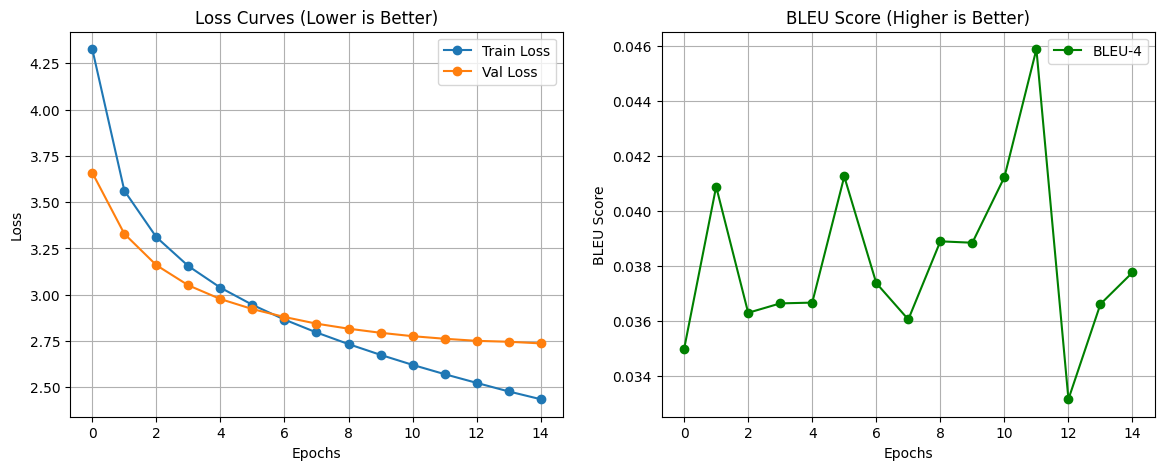

📂 Images found at: /kaggle/input/datasets/adityajn105/flickr30k/Images

🖼️ Generating Examples (Loading Original Images)...


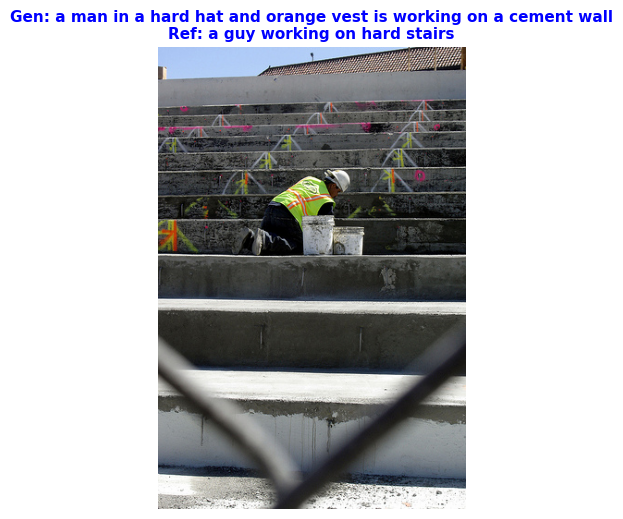

------------------------------------------------------------


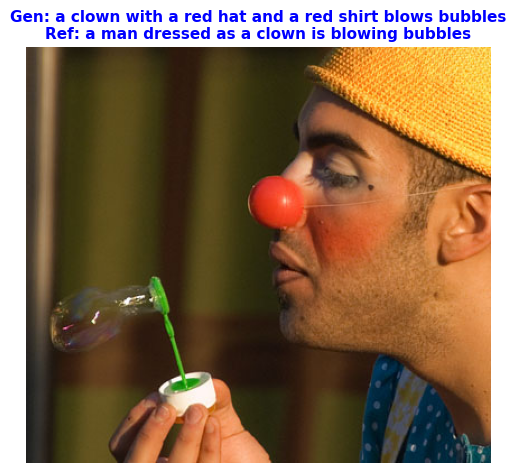

------------------------------------------------------------


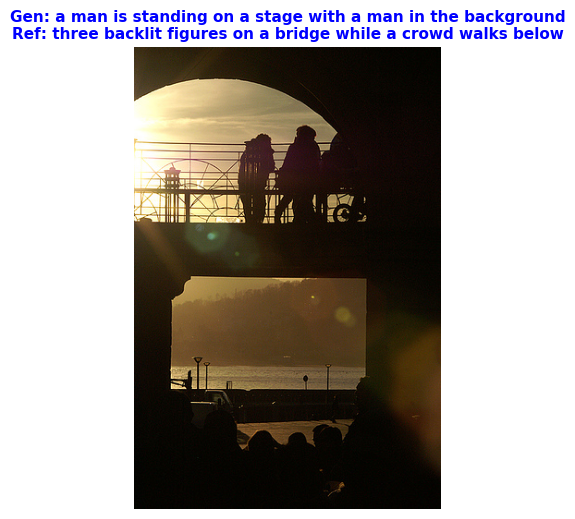

------------------------------------------------------------


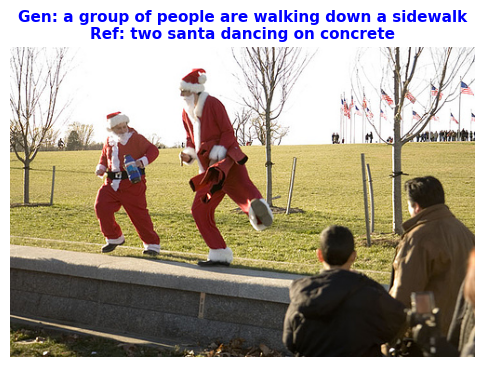

------------------------------------------------------------


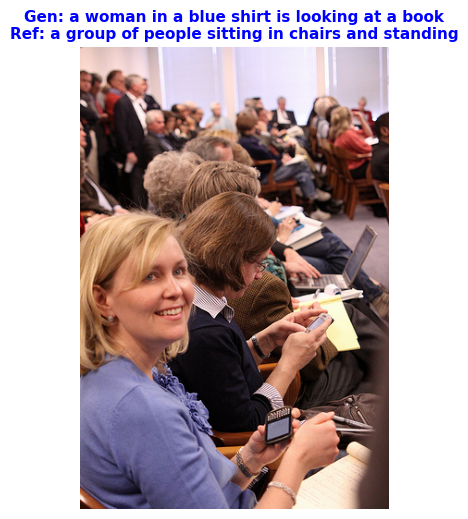

------------------------------------------------------------


In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import os
from PIL import Image

# --- 1. SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# --- 2. PLOT GRAPHS (LOSS & BLEU) ---
print("📊 Plotting Training Metrics...")
plt.figure(figsize=(14, 5))

# Graph 1: Loss Curve
plt.subplot(1, 2, 1)
if 'history' in globals() and 'train_loss' in history:
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Val Loss', marker='o')
    plt.title('Loss Curves (Lower is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
else:
    plt.text(0.5, 0.5, 'Loss Data Missing', ha='center')

# Graph 2: BLEU Score Curve (Yeh naya add kiya hai)
plt.subplot(1, 2, 2)
if 'history' in globals() and 'bleu' in history and len(history['bleu']) > 0:
    plt.plot(history['bleu'], label='BLEU-4', color='green', marker='o')
    plt.title('BLEU Score (Higher is Better)')
    plt.xlabel('Epochs')
    plt.ylabel('BLEU Score')
    plt.legend()
    plt.grid(True)
else:
    plt.text(0.5, 0.5, 'BLEU Score Data Missing', ha='center')
    plt.title('BLEU Score')
    plt.grid(True)

plt.show()

# --- 3. IMAGE DIRECTORY SETUP ---
# Kaggle Input directory find karna
image_dir = '/kaggle/input/flickr8k/Images' # Default guess
if not os.path.exists(image_dir):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'Images' in dirs:
            image_dir = os.path.join(root, 'Images')
            break
        if len(files) > 1000 and files[0].endswith('.jpg'):
             image_dir = root
             break
print(f"📂 Images found at: {image_dir}")

# --- 4. HELPER TO GET FILENAME ---
def get_image_filename(dataset, idx):
    if hasattr(dataset, 'dataset'):
        real_idx = dataset.indices[idx]
        main_ds = dataset.dataset
    else:
        real_idx = idx
        main_ds = dataset
    
    if hasattr(main_ds, 'imgs'): return main_ds.imgs[real_idx]
    elif hasattr(main_ds, 'ids'): return main_ds.ids[real_idx]
    elif hasattr(main_ds, 'images'): return main_ds.images[real_idx]
    else: return None

# --- 5. GENERATE & SHOW EXAMPLES ---
print("\n🖼️ Generating Examples (Loading Original Images)...")

dataset = val_loader.dataset
indices = np.random.choice(len(dataset), 5, replace=False)

for idx in indices:
    # 1. Get Feature & Caption
    feature_tensor, caption_tensor = dataset[idx]
    
    # 2. Generate Caption
    feature_gpu = feature_tensor.unsqueeze(0).to(device)
    try:
        gen_words = generate_caption_att(model, feature_gpu.squeeze(0), vocab)
        gen_text = " ".join(gen_words)
    except Exception as e:
        gen_text = f"<Gen Error: {e}>"

    # 3. Get Real Caption
    gt_words = [vocab.itos[i.item()] for i in caption_tensor if vocab.itos[i.item()] not in ['<start>', '<end>', '<pad>']]
    ref_text = " ".join(gt_words)
    
    # 4. Load & Show Image
    img_filename = get_image_filename(dataset, idx)
    
    if img_filename:
        full_path = os.path.join(image_dir, img_filename)
        try:
            pil_image = Image.open(full_path).convert("RGB")
            
            plt.figure(figsize=(6, 6))
            plt.imshow(pil_image)
            plt.axis('off')
            plt.title(f"Gen: {gen_text}\nRef: {ref_text}", color='blue', fontsize=11, fontweight='bold')
            plt.show()
            print("-" * 60)
            
        except Exception as e:
            print(f"⚠️ Image load error ({img_filename}): {e}")
    else:
        print(f"⚠️ Filename not found for index {idx}")

In [21]:
!pip install gradio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 9.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 46.9 MB/s eta 0:00:0000:01
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.5
    Uninstalling pydantic-2.12.5:
      Successfully uninstalled pydantic-2.12.5
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
langchain-core 0.3.79 requires packaging<26.0.0,>=23.2.0, but you have packaging 26.0rc2 which is incompatible.
fastai 2.8.4 requires fastcore

In [23]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import pickle
import os

# --- 1. CONFIGURATION ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚙️ System Reset. Running on: {device}")

vocab_path = '/kaggle/working/vocab.pkl'
model_path = '/kaggle/working/attention_model_best.pth'

# --- 2. CHECK IF FILES EXIST ---
if os.path.exists(vocab_path) and os.path.exists(model_path):
    print("✅ Saved Files Found! Loading them now...")
else:
    print("❌ Files nahi milin! Kya aapne session band kar diya tha?")
    # Agar files nahi milti to shayad session disconnect ho gaya tha.

# --- 3. DEFINE MODELS (Fixed Names for Loading) ---
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        self.linear = nn.Linear(2048, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
    def forward(self, images):
        features = self.linear(images)
        return self.relu(features)

class Attention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super(Attention, self).__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden)
        att = self.full_att(self.relu(att1 + att2.unsqueeze(1))).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, attention_dim):
        super(DecoderRNN, self).__init__()
        self.vocab_size = vocab_size
        self.attention = Attention(2048, hidden_size, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # ✅ FIX: Using 'lstm_cell' to match your saved file
        self.lstm_cell = nn.LSTMCell(embed_size + 2048, hidden_size)
        
        self.init_h = nn.Linear(2048, hidden_size)
        self.init_c = nn.Linear(2048, hidden_size)
        self.f_beta = nn.Linear(hidden_size, 2048)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, features, captions):
        pass 

class FeatureExtractor(nn.Module):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # Warning hatane ke liye naya method
        resnet = models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V1)
        modules = list(resnet.children())[:-2] 
        self.resnet = nn.Sequential(*modules)
    def forward(self, x):
        return self.resnet(x)

# --- 4. LOAD SAVED WEIGHTS ---
print("⏳ Loading Vocab & Models...")

# Load Vocab
with open(vocab_path, 'rb') as f:
    vocab = pickle.load(f)

# Load Encoder
encoder = FeatureExtractor().to(device)
encoder.eval()

# Load Decoder
embed_size = 256
hidden_size = 512
vocab_size = len(vocab)
attention_dim = 256

model = DecoderRNN(embed_size, hidden_size, vocab_size, attention_dim).to(device)

# Load Checkpoint
checkpoint = torch.load(model_path, map_location=device)
if 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)
model.eval()

print("✅ All Models Loaded Successfully!")

# --- 5. PREDICTION LOGIC ---
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

def generate_caption_att(model, features, vocab, max_len=20):
    h = model.init_h(features.mean(dim=1))
    c = model.init_c(features.mean(dim=1))
    captions = []
    
    word = torch.tensor([vocab.stoi['<start>']]).to(device)
    embeds = model.embedding(word)
    
    for _ in range(max_len):
        context, alpha = model.attention(features, h)
        gate = torch.sigmoid(model.f_beta(h))
        gated_context = gate * context
        lstm_input = torch.cat((embeds, gated_context), dim=1)
        
        # ✅ FIX: Using lstm_cell here
        h, c = model.lstm_cell(lstm_input, (h, c))
        
        output = model.fc(model.dropout(h))
        predicted = output.argmax(1)
        
        word_str = vocab.itos[predicted.item()]
        if word_str == '<end>':
            break
        
        if word_str not in ['<start>', '<pad>']:
            captions.append(word_str)
            
        embeds = model.embedding(predicted)
    
    return captions

def predict_caption(image):
    if image is None: return "Please upload an image."
    try:
        img_t = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            features = encoder(img_t)
            features = features.permute(0, 2, 3, 1)
            features = features.view(features.size(0), -1, features.size(-1))
            output = generate_caption_att(model, features, vocab)
        return " ".join(output).capitalize()
    except Exception as e:
        return f"Error: {str(e)}"

# --- 6. LAUNCH ---
print("\n🚀 Starting Interface (Wait 20s for link)...")
gr.close_all() # Safest way
interface = gr.Interface(
    fn=predict_caption,
    inputs=gr.Image(type="pil", label="Upload Photo"),
    outputs=gr.Textbox(label="Result"),
    title="AI Caption Generator",
    description="Final Working Version"
)

interface.queue().launch(share=True, debug=True)

📂 Loading Model from: /kaggle/working/attention_model_best.pth
✅ Model Weights Loaded Successfully!
⏳ Loading Encoder...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Encoder Ready!
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9c17990ba63f95be66.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://9c17990ba63f95be66.gradio.live
